# Notebook 01 — Basic Fourier analysis of a triangular wave

This notebook introduces the numerical computation of Fourier coefficients for a periodic triangular signal.

We will:

- define a symmetric triangular wave,
- compute its real Fourier coefficients numerically,
- reconstruct the signal with a finite number of harmonics,
- inspect its magnitude and phase spectra,
- and evaluate the reconstruction error as the number of harmonics increases.

This notebook is part of the computational laboratory accompanying the monograph.

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Signal definition

We begin with a symmetric triangular wave of amplitude \(A=2\) and frequency \(f_0=60\text{ Hz}\).

The goal is to use this signal as a simple periodic prototype whose harmonic structure can be explored numerically.

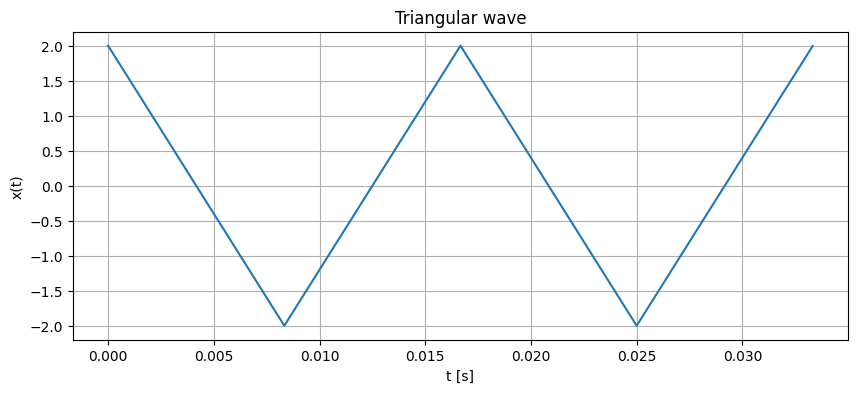

In [2]:
def triangular_wave(t, amplitude=2.0, frequency=60.0):
    T = 1.0 / frequency
    x = (t / T) % 1.0
    return amplitude * (4.0 * np.abs(x - 0.5) - 1.0)

A = 2.0
f0 = 60.0
w0 = 2 * np.pi * f0

T0 = 1.0 / f0
t = np.linspace(0, 2*T0, 4000, endpoint=False)
x = triangular_wave(t, amplitude=A, frequency=f0)

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title("Triangular wave")
plt.xlabel("t [s]")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

## 2. Numerical Fourier coefficients

For a periodic signal \(x(t)\) of period \(T\), we use the real Fourier expansion

$$
x(t)=\frac{a_0}{2}+\sum_{k=1}^{\infty}\left[a_k\cos(k\omega_0 t)+b_k\sin(k\omega_0 t)\right],
\qquad \omega_0=\frac{2\pi}{T}.
$$

The coefficients are computed numerically using trapezoidal integration.

In [3]:
def fourier_coefficients(func, T, N, num_points=20000):
    t = np.linspace(0, T, num_points, endpoint=False)
    x = func(t)

    a0 = (2.0 / T) * np.trapezoid(x, t)

    an = np.zeros(N)
    bn = np.zeros(N)

    for n in range(1, N + 1):
        an[n - 1] = (2.0 / T) * np.trapezoid(x * np.cos(2 * np.pi * n * t / T), t)
        bn[n - 1] = (2.0 / T) * np.trapezoid(x * np.sin(2 * np.pi * n * t / T), t)

    return a0, an, bn

## 3. Numerical coefficients

We compute the first \(N\) Fourier coefficients of the triangular wave.

In [4]:
N = 15

func = lambda tt: triangular_wave(tt, amplitude=A, frequency=f0)
a0, an, bn = fourier_coefficients(func, T0, N)

print("a0 =", a0)

a0 = -0.00019997999999965543


## 4. Harmonic structure

From the coefficients \(a_k\) and \(b_k\), we define the harmonic magnitude and phase as

$$
I_k = \sqrt{a_k^2+b_k^2},
\qquad
\phi_k = \operatorname{atan2}(-b_k,a_k).
$$

The following table summarizes the first harmonics.

In [5]:
k = np.arange(1, N + 1)
Ik = np.sqrt(an**2 + bn**2)
phik = np.arctan2(-bn, an)

In [ ]:


df_fourier = pd.DataFrame({
    "k": k,
    "a_k": an,
    "b_k": bn,
    "I_k": Ik,
    "phi_k_rad": phik
})

df_fourier["parity"] = df_fourier["k"].apply(lambda kk: "odd" if kk % 2 == 1 else "even")

df_fourier.style.format({
    "a_k": "{:.6e}",
    "b_k": "{:.6e}",
    "I_k": "{:.6e}",
    "phi_k_rad": "{:.6e}"
})

## 4. Harmonic structure

From the coefficients \(a_k\) and \(b_k\), we define the harmonic magnitude and phase as

$$
I_k = \sqrt{a_k^2+b_k^2},
\qquad
\phi_k = \operatorname{atan2}(-b_k,a_k).
$$

The following table summarizes the first harmonics.

## 5. Reconstruction with a finite number of harmonics

A truncated Fourier series provides an approximation of the original signal. This allows us to observe how the waveform is progressively rebuilt as more harmonics are retained.

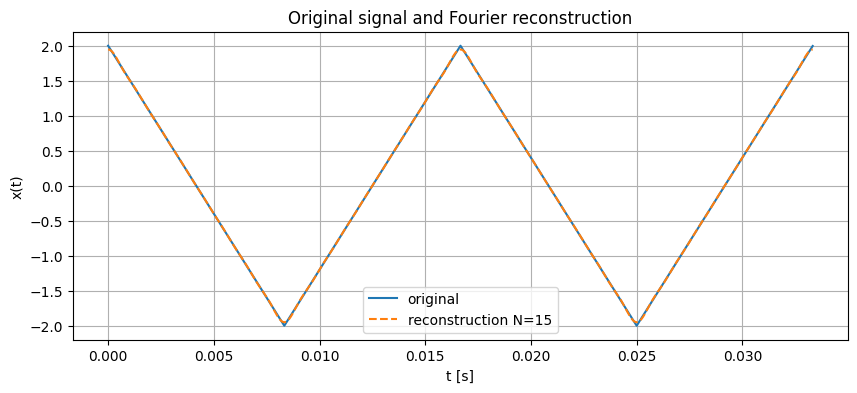

In [7]:
def reconstruct_signal(t, T, a0, an, bn):
    x_rec = 0.5 * a0 * np.ones_like(t)
    N = len(an)
    for n in range(1, N + 1):
        x_rec += an[n - 1] * np.cos(2 * np.pi * n * t / T)
        x_rec += bn[n - 1] * np.sin(2 * np.pi * n * t / T)
    return x_rec

x_rec = reconstruct_signal(t, T0, a0, an, bn)

plt.figure(figsize=(10, 4))
plt.plot(t, x, label="original")
plt.plot(t, x_rec, "--", label=f"reconstruction N={N}")
plt.title("Original signal and Fourier reconstruction")
plt.xlabel("t [s]")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

## 6. Magnitude and phase spectra

We now visualize the harmonic content of the triangular wave in terms of magnitude and phase.

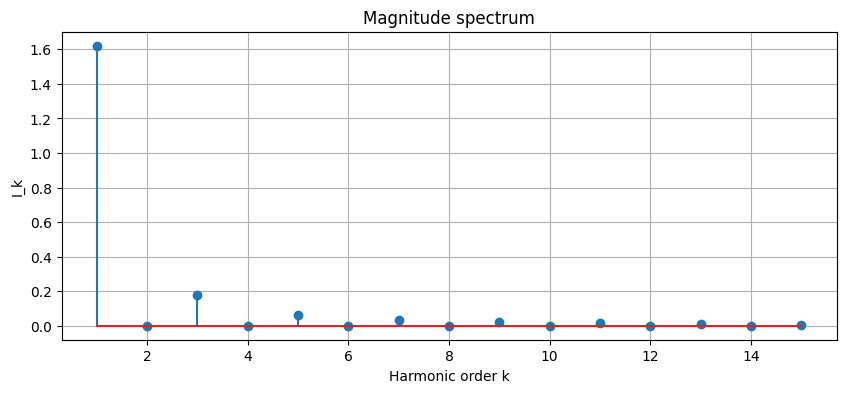

In [8]:
plt.figure(figsize=(10, 4))
plt.stem(k, Ik)
plt.title("Magnitude spectrum")
plt.xlabel("Harmonic order k")
plt.ylabel("I_k")
plt.grid(True)
plt.show()

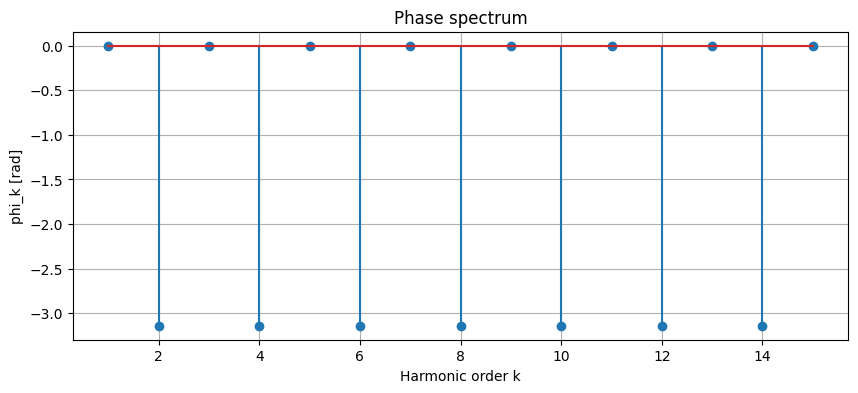

In [9]:
plt.figure(figsize=(10, 4))
plt.stem(k, phik)
plt.title("Phase spectrum")
plt.xlabel("Harmonic order k")
plt.ylabel("phi_k [rad]")
plt.grid(True)
plt.show()

## 7. Effect of truncation

To better understand the role of harmonic truncation, we compare reconstructions obtained with different numbers of retained harmonics.

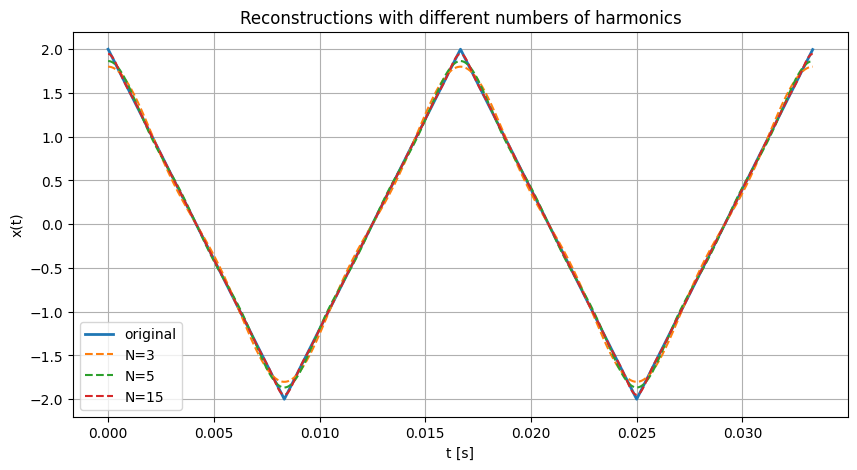

In [10]:
Ns = [3, 5, 15]

plt.figure(figsize=(10, 5))
plt.plot(t, x, label="original", linewidth=2)

for NN in Ns:
    a0N, anN, bnN = fourier_coefficients(func, T0, NN)
    xN = reconstruct_signal(t, T0, a0N, anN, bnN)
    plt.plot(t, xN, "--", label=f"N={NN}")

plt.title("Reconstructions with different numbers of harmonics")
plt.xlabel("t [s]")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

## 8. Reconstruction error

We estimate the relative \(L^2\) error between the original signal and its truncated Fourier reconstruction.

In [11]:
def relative_l2_error(x_true, x_approx):
    return np.linalg.norm(x_true - x_approx) / np.linalg.norm(x_true)

errors = []

for NN in [1, 3, 5, 9, 15, 25]:
    a0N, anN, bnN = fourier_coefficients(func, T0, NN)
    xN = reconstruct_signal(t, T0, a0N, anN, bnN)
    err = relative_l2_error(x, xN)
    errors.append((NN, err))

df_errors = pd.DataFrame(errors, columns=["N_harmonics", "relative_L2_error"])
df_errors.style.format({"relative_L2_error": "{:.6e}"})

,N_harmonics,relative_L2_error
0,1,1.202750e-01
1,3,4.794643e-02
2,5,2.686958e-02
3,9,1.270052e-02
4,15,6.330635e-03
5,25,3.119948e-03


## 9. Significant harmonics

Finally, we filter the harmonic table to keep only coefficients whose magnitude is above a chosen threshold.

In [12]:
threshold = 1e-3
df_significant = df_fourier[df_fourier["I_k"] > threshold].copy()

df_significant.style.format({
    "a_k": "{:.6e}",
    "b_k": "{:.6e}",
    "I_k": "{:.6e}",
    "phi_k_rad": "{:.6e}"
})

,k,a_k,b_k,I_k,phi_k_rad,parity
0,1,1.620939e+00,3.140964e-08,1.620939e+00,-1.937744e-08,odd
2,3,1.799266e-01,9.422892e-08,1.799266e-01,-5.237076e-07,odd
4,5,6.464559e-02,1.570482e-07,6.464559e-02,-2.429371e-06,odd
6,7,3.288450e-02,2.198673e-07,3.288450e-02,-6.686047e-06,odd
8,9,1.981409e-02,2.826864e-07,1.981409e-02,-1.426694e-05,odd
10,11,1.319788e-02,3.455054e-07,1.319788e-02,-2.617886e-05,odd
12,13,9.392572e-03,4.083242e-07,9.392572e-03,-4.347310e-05,odd
14,15,7.005096e-03,4.711429e-07,7.005096e-03,-6.725716e-05,odd
